In [1]:
import socket
print(f"Running on: {socket.gethostname()}")

Running on: damnii03.inf.ed.ac.uk


In [2]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


## Import Necessary Modules

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import T5Tokenizer, T5ForConditionalGeneration # huggingface T5 model + tokenizer
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import torchmetrics
from initial_model import MultitaskModel, MultitaskDataset, create_weighted_sampler, get_parameter_groups, evaluate_with_sampling, setup_training_pipeline, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL
from sklearn.model_selection import train_test_split
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
import nltk
import random
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

## Set Random Seed, For Reproducibility

In [4]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Simple Description Dataset

### Load Dataset

In [5]:
mwr_df_simple = pd.read_csv('mwr_simple.csv')

### Extract Features

In [6]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df_simple.columns if col.endswith('int') or col.endswith('sk')]
mwr_df_simple['features'] = mwr_df_simple[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df_simple['class_label'] = mwr_df_simple['y_binary'].astype(int)
mwr_df_simple['synthetic_description'] = mwr_df_simple['Synthetic_Conclusion']

### Split into Training, Test and Validation Splits

In [7]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_simple_df, temp_simple_df = train_test_split(
    mwr_df_simple, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df_simple['r:Th']
)

val_simple_df, test_simple_df = train_test_split(
    temp_simple_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_simple_df['r:Th']
)

In [8]:
# check class distribution
print(mwr_df_simple['class_label'].value_counts(normalize=True))
print(train_simple_df['synthetic_description'].value_counts())

class_label
1    0.75883
0    0.24117
Name: proportion, dtype: float64
synthetic_description
Moderately elevated temperature (surface).                                 4996
Slightly elevated temperature.                                             4904
No thermal changes detected.                                               4091
Increased temperature (surface and depth), partial asymmetry.              1363
Increased temperature (surface and depth), greater and clear asymmetry.    1102
Moderately elevated temperature (surface and depth).                        509
Name: count, dtype: int64


### Initialise Model

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = setup_training_pipeline(
    df_train=train_simple_df,
    df_val=val_simple_df,
    df_test=test_simple_df,
    multitask_model_class=MultitaskModel,
    multitask_dataset_class=MultitaskDataset
)

Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Creating datasets...
Creating dataloaders...
Setting up device...
Initializing model...
Initial weights - CLF: 0.1, GEN: 10
Moving model to device...


KeyboardInterrupt: 

### Train Model

In [ ]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [ ]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_simple_df)

In [ ]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)

## Temperature-based Description Dataset

In [5]:
mwr_df_temps = pd.read_csv('mwr_temps.csv')

### Extract Features

In [6]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df_temps.columns if col.endswith('int') or col.endswith('sk')]
mwr_df_temps['features'] = mwr_df_temps[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df_temps['class_label'] = mwr_df_temps['y_binary'].astype(int)
mwr_df_temps['synthetic_description'] = mwr_df_temps['Synthetic_Conclusion']

### Split into Training, Test and Validation Splits

In [7]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_temps_df, temp_temps_df = train_test_split(
    mwr_df_temps, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df_temps['r:Th']
)

val_temps_df, test_temps_df = train_test_split(
    temp_temps_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_temps_df['r:Th']
)

### Initialise Model

In [8]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = setup_training_pipeline(
    df_train=train_temps_df,
    df_val=val_temps_df,
    df_test=test_temps_df,
    multitask_model_class=MultitaskModel,
    multitask_dataset_class=MultitaskDataset
)

Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Creating datasets...
Creating dataloaders...
Setting up device...
Initializing model...
Initial weights - CLF: 0.1, GEN: 10
Moving model to device...
Setting up optimizer...
After .to(device) - CLF: 0.1, GEN: 10
✓ Setup complete!



### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 5.6530
Classification loss: 0.6044
Generation loss: 0.5593
Weighted gen loss: 5.592555
Validation loss: 0.5447
Validation metrics:
  Accuracy     : 0.7249
  F1-Score     : 0.7184
  Sensitivity  : 0.8387
  Specificity  : 0.3672
  AUC-ROC      : 0.7079

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.3786
  ✓ New best METEOR: 0.3786
  ROUGE-L F1   : 0.4136
  ✓ New best ROUGE-L F1: 0.4136
✓ New best accuracy: 0.7249
✓ New best F1: 0.7184
✓ New best AUC-ROC: 0.7079

Epoch 2/50
Training loss: 0.5650
Classification loss: 0.5508
Generation loss: 0.0510
Weighted gen loss: 0.509948
Validation loss: 0.4651
Validation metrics:
  Accuracy     : 0.7604
  F1-Score     : 0.7427
  Sensitivity  : 0.8945
  Specificity  : 0.3387
  AUC-ROC      : 0.7318

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
 

Training loss: 0.4250
Classification loss: 0.4680
Generation loss: 0.0378
Weighted gen loss: 0.378168
Validation loss: 0.4075
Validation metrics:
  Accuracy     : 0.7700
  F1-Score     : 0.7782
  Sensitivity  : 0.8075
  Specificity  : 0.6522
  AUC-ROC      : 0.8128

--- Text Evaluation (Epoch 16) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4676
  ✓ New best METEOR: 0.4676
  ROUGE-L F1   : 0.4981
  ✓ New best ROUGE-L F1: 0.4981
✓ New best AUC-ROC: 0.8128

Epoch 17/50
Training loss: 0.4226
Classification loss: 0.4677
Generation loss: 0.0376
Weighted gen loss: 0.375850
Validation loss: 0.4046
Validation metrics:
  Accuracy     : 0.7651
  F1-Score     : 0.7726
  Sensitivity  : 0.8093
  Specificity  : 0.6260
  AUC-ROC      : 0.8130

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4516
  ROUGE-L F1   : 0.4874


Training loss: 0.3888
Classification loss: 0.4476
Generation loss: 0.0344
Weighted gen loss: 0.344038
Validation loss: 0.3879
Validation metrics:
  Accuracy     : 0.7758
  F1-Score     : 0.7845
  Sensitivity  : 0.8067
  Specificity  : 0.6784
  AUC-ROC      : 0.8383

--- Text Evaluation (Epoch 32) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4889
  ✓ New best METEOR: 0.4889
  ROUGE-L F1   : 0.5118
✓ New best AUC-ROC: 0.8383

Epoch 33/50
Training loss: 0.3854
Classification loss: 0.4414
Generation loss: 0.0341
Weighted gen loss: 0.341253
Validation loss: 0.3912
Validation metrics:
  Accuracy     : 0.7873
  F1-Score     : 0.7913
  Sensitivity  : 0.8408
  Specificity  : 0.6192
  AUC-ROC      : 0.8323

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4796
  ROUGE-L F1   : 0.5001
Current loss weights - CLF: 0.10

Computing text metrics on 3635 samples...
  METEOR Score : 0.4929
  ROUGE-L F1   : 0.5214
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 49/50
Training loss: 0.3658
Classification loss: 0.4229
Generation loss: 0.0324
Weighted gen loss: 0.323514
Validation loss: 0.3832
Validation metrics:
  Accuracy     : 0.7860
  F1-Score     : 0.7927
  Sensitivity  : 0.8241
  Specificity  : 0.6659
  AUC-ROC      : 0.8403

--- Text Evaluation (Epoch 49) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4881
  ROUGE-L F1   : 0.5126

Epoch 50/50
Training loss: 0.3640
Classification loss: 0.4202
Generation loss: 0.0322
Weighted gen loss: 0.321981
Validation loss: 0.3883
Validation metrics:
  Accuracy     : 0.7755
  F1-Score     : 0.7856
  Sensitivity  : 0.7962
  Specificity  : 0.7104
  AUC-ROC      : 0.8402

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3

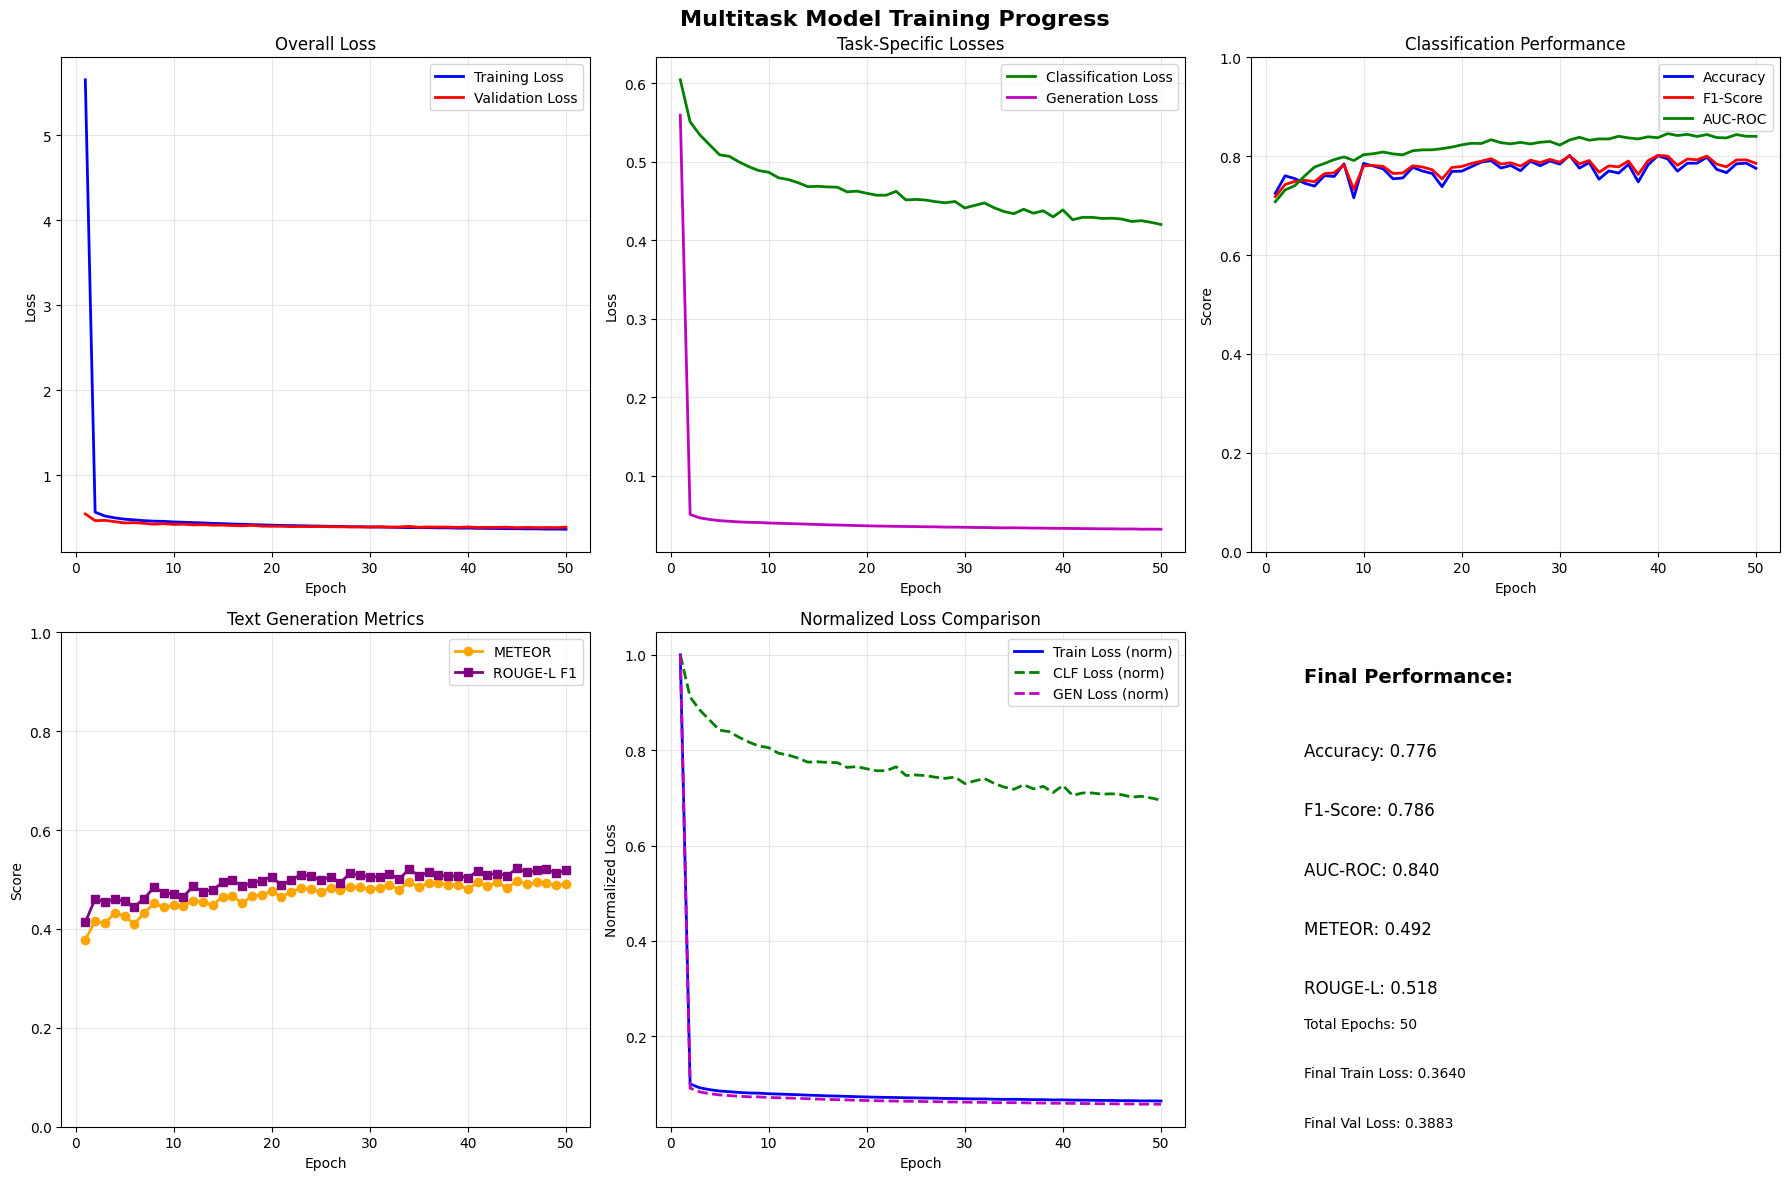


TRAINING SUMMARY
Best Accuracy: 0.8017
Best F1-Score: 0.8017
Best AUC-ROC: 0.8457
Best METEOR: 0.4971
Best ROUGE-L: 0.5224


In [9]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [11]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_temps_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 0.3922
Classification metrics (all 3636 samples):
  Accuracy     : 0.7723
  F1-Score     : 0.7818
  Sensitivity  : 0.7996
  Specificity  : 0.6864
  AUC-ROC      : 0.8318

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3636 samples)
Computing text metrics on 3636 samples...
Text generation metrics (3636 samples):
  ROUGE-L F1   : 0.5105
  METEOR       : 0.4824

Sample efficiency: 3636/3636 samples used for text metrics


In [12]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : Low-grade thermal anomalies present. Internal temperatures elevated relative to surface.
Reference : No thermal changes detected. Internal temps exceed surface, but within low-risk expectations.
----------------------------------------

Sample 457
----------------------------------------
Generated : Very mild regional irregularities observed. Slight internal surface disparity.
Reference : Very mild regional irregularities observed. Slight internal surface disparity.
----------------------------------------

Sample 103
----------------------------------------
Generated : Low-grade thermal anomalies present. Internal temperatures elevated relative to surface.
Reference : Low-grade thermal anomalies present. Internal temperatures elevated relative to surface.
----------------------------------------

Sample 3038
----------------------------------------
Generated : Ve

### Advanced Description Dataset

### Load Dataset

In [5]:
mwr_df_adv = pd.read_csv('mwr_adv.csv')

### Extract Features

In [6]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df_adv.columns if col.endswith('int') or col.endswith('sk')]
mwr_df_adv['features'] = mwr_df_adv[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df_adv['class_label'] = mwr_df_adv['y_binary'].astype(int)
mwr_df_adv['synthetic_description'] = mwr_df_adv['Enhanced_Synthetic_Conclusion']

### Split into Training, Validation and Test Splits

In [7]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_adv_df, temp_adv_df = train_test_split(
    mwr_df_adv, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df_adv['r:Th']
)

val_adv_df, test_adv_df = train_test_split(
    temp_adv_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_adv_df['r:Th']
)

### Initialise Model

In [8]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = setup_training_pipeline(
    df_train=train_adv_df,
    df_val=val_adv_df,
    df_test=test_adv_df,
    multitask_model_class=MultitaskModel,
    multitask_dataset_class=MultitaskDataset
)

Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Creating datasets...
Creating dataloaders...
Setting up device...
Initializing model...
Initial weights - CLF: 0.1, GEN: 10
Moving model to device...
Setting up optimizer...
After .to(device) - CLF: 0.1, GEN: 10
✓ Setup complete!



### Initialise Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 8.1689
Classification loss: 0.6041
Generation loss: 0.8108
Weighted gen loss: 8.108448
Validation loss: 1.0225
Validation metrics:
  Accuracy     : 0.7252
  F1-Score     : 0.7265
  Sensitivity  : 0.8144
  Specificity  : 0.4447
  AUC-ROC      : 0.7177

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.3445
  ✓ New best METEOR: 0.3445
  ROUGE-L F1   : 0.4369
  ✓ New best ROUGE-L F1: 0.4369
✓ New best accuracy: 0.7252
✓ New best F1: 0.7265
✓ New best AUC-ROC: 0.7177

Epoch 2/50
Training loss: 1.3107
Classification loss: 0.5534
Generation loss: 0.1255
Weighted gen loss: 1.255336
Validation loss: 0.8123
Validation metrics:
  Accuracy     : 0.7607
  F1-Score     : 0.7399
  Sensitivity  : 0.9017
  Specificity  : 0.3170
  AUC-ROC      : 0.7321

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
 

Computing text metrics on 3635 samples...
  METEOR Score : 0.4778
  ✓ New best METEOR: 0.4778
  ROUGE-L F1   : 0.5326
  ✓ New best ROUGE-L F1: 0.5326

Epoch 17/50
Training loss: 0.6798
Classification loss: 0.4662
Generation loss: 0.0633
Weighted gen loss: 0.633148
Validation loss: 0.6394
Validation metrics:
  Accuracy     : 0.7675
  F1-Score     : 0.7742
  Sensitivity  : 0.8154
  Specificity  : 0.6169
  AUC-ROC      : 0.8116

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4877
  ✓ New best METEOR: 0.4877
  ROUGE-L F1   : 0.5307
✓ New best AUC-ROC: 0.8116

Epoch 18/50
Training loss: 0.6759
Classification loss: 0.4652
Generation loss: 0.0629
Weighted gen loss: 0.629357
Validation loss: 0.6365
Validation metrics:
  Accuracy     : 0.7334
  F1-Score     : 0.7489
  Sensitivity  : 0.7422
  Specificity  : 0.7058
  AUC-ROC      : 0.8090

--- Text Evaluation (Epoch 18) ---
Evaluating text g

Computing text metrics on 3635 samples...
  METEOR Score : 0.5035
  ROUGE-L F1   : 0.5488
✓ New best AUC-ROC: 0.8324

Epoch 33/50
Training loss: 0.6199
Classification loss: 0.4430
Generation loss: 0.0576
Weighted gen loss: 0.575614
Validation loss: 0.6071
Validation metrics:
  Accuracy     : 0.7923
  F1-Score     : 0.7924
  Sensitivity  : 0.8626
  Specificity  : 0.5713
  AUC-ROC      : 0.8287

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.4999
  ROUGE-L F1   : 0.5522
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 0.6204
Classification loss: 0.4369
Generation loss: 0.0577
Weighted gen loss: 0.576701
Validation loss: 0.6140
Validation metrics:
  Accuracy     : 0.7673
  F1-Score     : 0.7773
  Sensitivity  : 0.7944
  Specificity  : 0.6819
  AUC-ROC      : 0.8302

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3635 samples)


Validation loss: 0.5906
Validation metrics:
  Accuracy     : 0.7934
  F1-Score     : 0.7980
  Sensitivity  : 0.8405
  Specificity  : 0.6454
  AUC-ROC      : 0.8424

--- Text Evaluation (Epoch 49) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.5277
  ROUGE-L F1   : 0.5633

Epoch 50/50
Training loss: 0.5906
Classification loss: 0.4209
Generation loss: 0.0549
Weighted gen loss: 0.548544
Validation loss: 0.5968
Validation metrics:
  Accuracy     : 0.7741
  F1-Score     : 0.7850
  Sensitivity  : 0.7897
  Specificity  : 0.7252
  AUC-ROC      : 0.8420

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3635 samples)
Computing text metrics on 3635 samples...
  METEOR Score : 0.5202
  ROUGE-L F1   : 0.5660


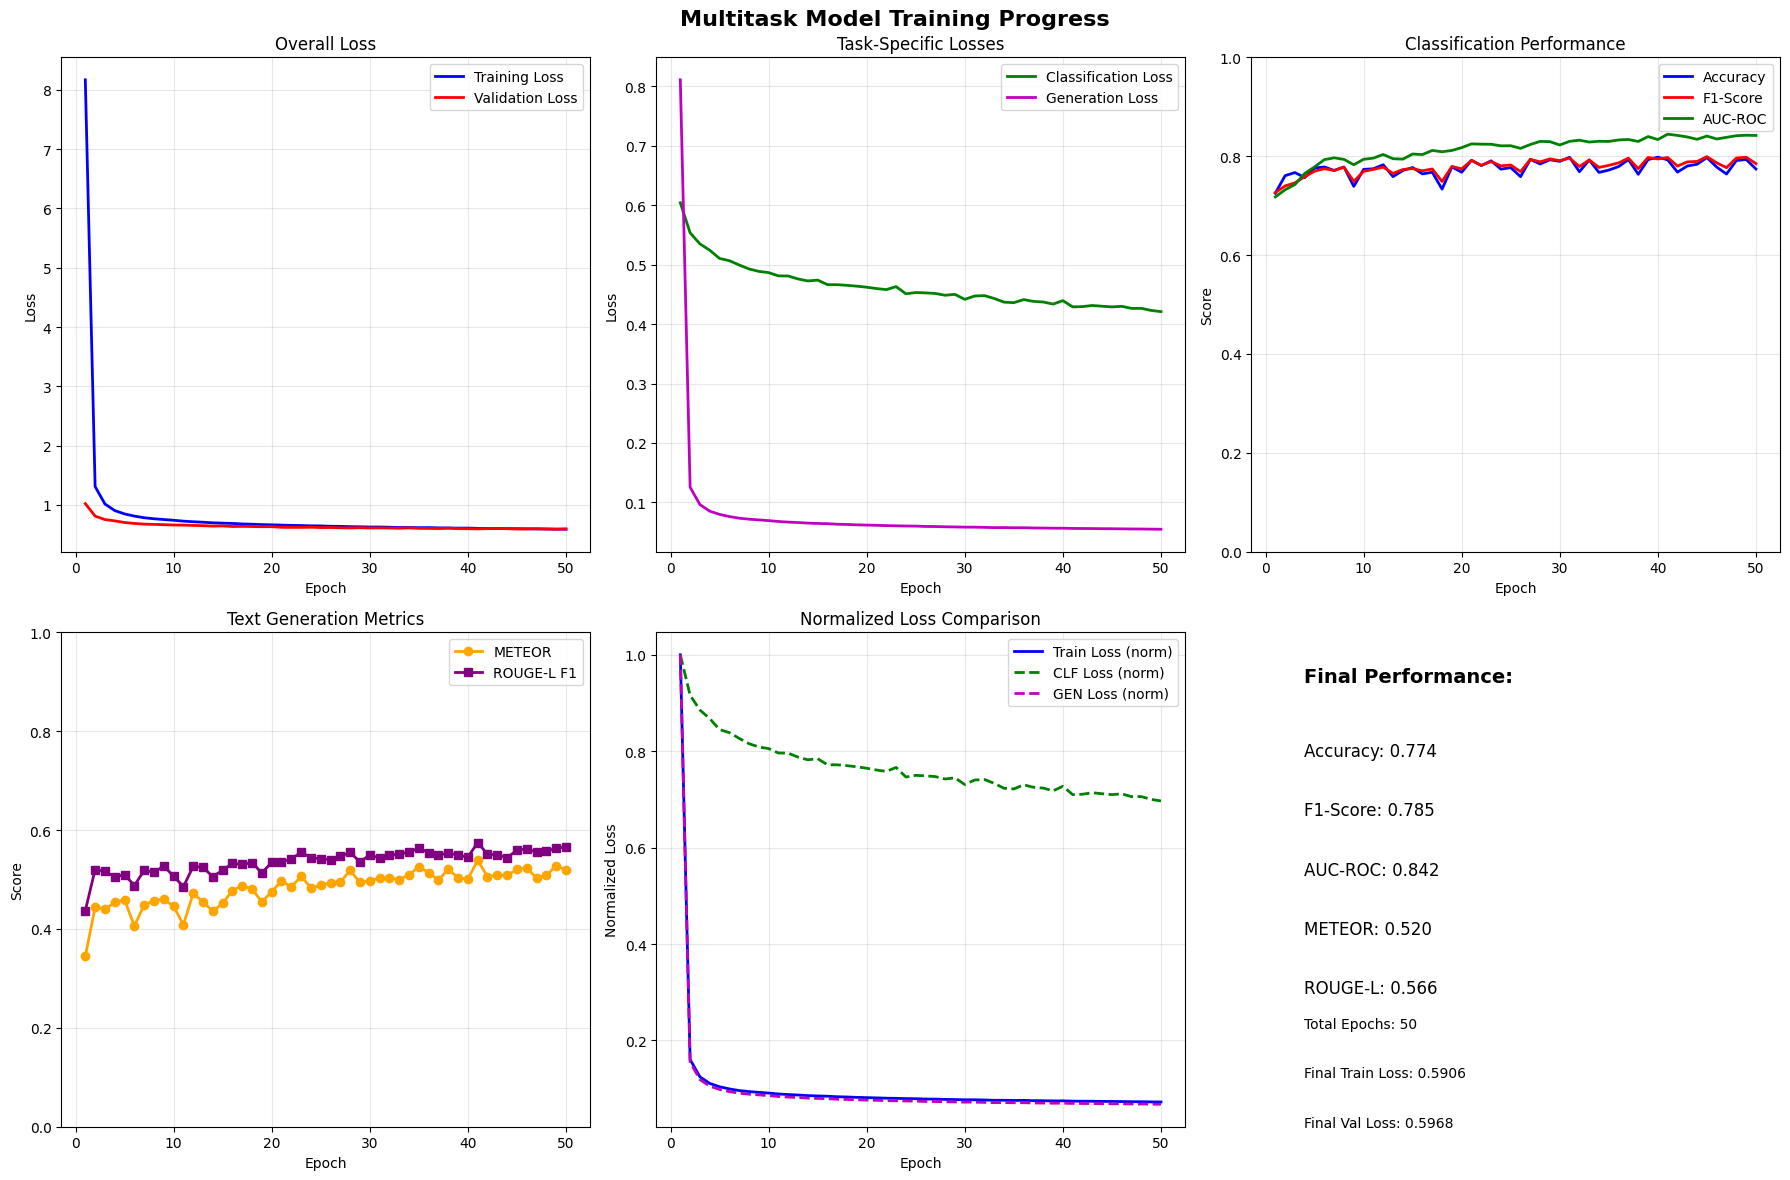


TRAINING SUMMARY
Best Accuracy: 0.7981
Best F1-Score: 0.7992
Best AUC-ROC: 0.8445
Best METEOR: 0.5389
Best ROUGE-L: 0.5745


In [9]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [10]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_adv_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 0.5949
Classification metrics (all 3636 samples):
  Accuracy     : 0.7698
  F1-Score     : 0.7804
  Sensitivity  : 0.7909
  Specificity  : 0.7035
  AUC-ROC      : 0.8341

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3636 samples)
Computing text metrics on 3636 samples...
Text generation metrics (3636 samples):
  ROUGE-L F1   : 0.5542
  METEOR       : 0.5072

Sample efficiency: 3636/3636 samples used for text metrics


In [11]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The temperature distribution is asymmetric, but there are no signs of locally elevated metabolism. I recommend regular self-examinations, regular clinical examinations by an oncologist, and systematic measurements in one year.
Reference : The temperature in both breasts is symmetrically distributed and within normal limits. The difference between deep and superficial values indicates normal tissue metabolism. There are no signs of local hyperthermia or abnormal thermal activity. I advise regular self-examinations immediately after menstruation and a systematic examination once
----------------------------------------

Sample 457
----------------------------------------
Generated : The temperature in both breasts is well distributed with minor variations from the average. I recommend self-examination once a month and a systematic check-up in one year or sooner if n

## Real Description Dataset

### Load Dataset

In [5]:
mwr_df = pd.read_csv('mwr.csv')

### Extract Features

In [6]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

### Split into Training, Validation and Test Splits

In [7]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

### Initialise Model

In [8]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = setup_training_pipeline(
    df_train=train_df,
    df_val=val_df,
    df_test=test_df,
    multitask_model_class=MultitaskModel,
    multitask_dataset_class=MultitaskDataset
)

Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Creating datasets...
Creating dataloaders...
Setting up device...
Initializing model...
Initial weights - CLF: 0.1, GEN: 10
Moving model to device...
Setting up optimizer...
After .to(device) - CLF: 0.1, GEN: 10
✓ Setup complete!



### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.4063
Classification loss: 0.6069
Generation loss: 1.8346
Weighted gen loss: 18.345644
Validation loss: 10.4484
Validation metrics:
  Accuracy     : 0.7412
  F1-Score     : 0.7262
  Sensitivity  : 0.8726
  Specificity  : 0.3295
  AUC-ROC      : 0.7012

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4214
  ✓ New best METEOR: 0.4214
  ROUGE-L F1   : 0.4137
  ✓ New best ROUGE-L F1: 0.4137
✓ New best accuracy: 0.7412
✓ New best F1: 0.7262
✓ New best AUC-ROC: 0.7012

Epoch 2/50
Training loss: 11.1459
Classification loss: 0.5550
Generation loss: 1.1090
Weighted gen loss: 11.090365
Validation loss: 9.1969
Validation metrics:
  Accuracy     : 0.7497
  F1-Score     : 0.7392
  Sensitivity  : 0.8682
  Specificity  : 0.3786
  AUC-ROC      : 0.7248

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.3980
  ROUGE-L F1   : 0.3988
✓ New best F1: 0.7766
✓ New best AUC-ROC: 0.7999

Epoch 17/50
Training loss: 7.2994
Classification loss: 0.4716
Generation loss: 0.7252
Weighted gen loss: 7.252277
Validation loss: 6.8667
Validation metrics:
  Accuracy     : 0.7804
  F1-Score     : 0.7789
  Sensitivity  : 0.8613
  Specificity  : 0.5268
  AUC-ROC      : 0.8035

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3895
  ROUGE-L F1   : 0.3942
✓ New best F1: 0.7789
✓ New best AUC-ROC: 0.8035

Epoch 18/50
Training loss: 7.2270
Classification loss: 0.4680
Generation loss: 0.7180
Weighted gen loss: 7.180242
Validation loss: 6.7687
Validation metrics:
  Accuracy     : 0.7737
  F1-Score     : 0.7690
  Sensitivity  : 0.8686
  Specificity  : 0.4766
  AUC-ROC      : 0.7990

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL

Computing text metrics on 3624 samples...
  METEOR Score : 0.3931
  ROUGE-L F1   : 0.3943
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.4432
Classification loss: 0.4421
Generation loss: 0.6399
Weighted gen loss: 6.399020
Validation loss: 6.2361
Validation metrics:
  Accuracy     : 0.7768
  F1-Score     : 0.7805
  Sensitivity  : 0.8355
  Specificity  : 0.5929
  AUC-ROC      : 0.8168

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3957
  ROUGE-L F1   : 0.4002
✓ New best F1: 0.7805
✓ New best AUC-ROC: 0.8168

Epoch 35/50
Training loss: 6.4128
Classification loss: 0.4432
Generation loss: 0.6368
Weighted gen loss: 6.368468
Validation loss: 6.1930
Validation metrics:
  Accuracy     : 0.7768
  F1-Score     : 0.7772
  Sensitivity  : 0.8507
  Specificity  : 0.5450
  AUC-ROC      : 0.8123

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL d

Computing text metrics on 3624 samples...
  METEOR Score : 0.3841
  ROUGE-L F1   : 0.3933
✓ New best AUC-ROC: 0.8244


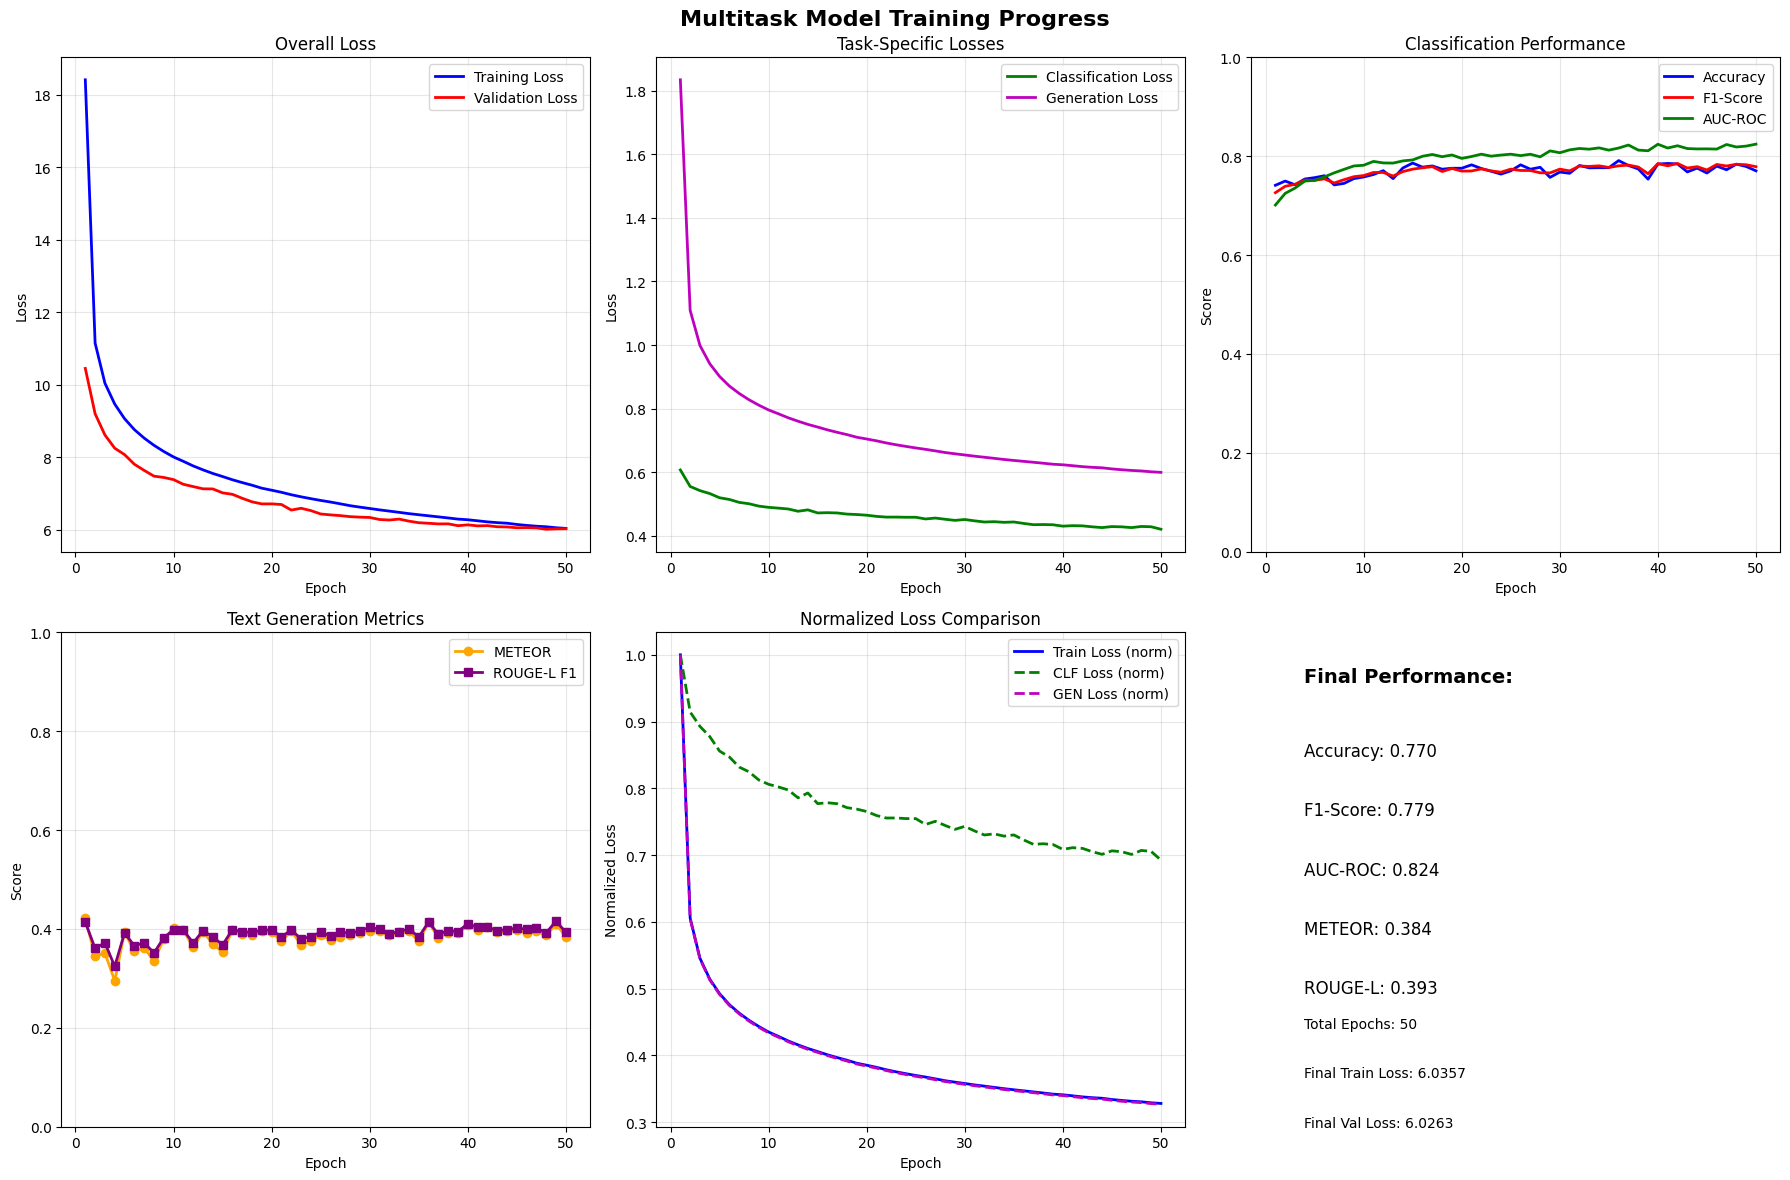


TRAINING SUMMARY
Best Accuracy: 0.7911
Best F1-Score: 0.7854
Best AUC-ROC: 0.8244
Best METEOR: 0.4214
Best ROUGE-L: 0.4155


In [9]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [10]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.9736
Classification metrics (all 3625 samples):
  Accuracy     : 0.7912
  F1-Score     : 0.7985
  Sensitivity  : 0.8221
  Specificity  : 0.6941
  AUC-ROC      : 0.8422

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3932
  METEOR       : 0.3835

Sample efficiency: 3625/3625 samples used for text metrics


In [11]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, the asymmetry is currently exceeded, therefore we recommend a comparative check in 6 months (09.2019). During this period, the lady will regularly self-examine and undergo a preventive mammogram. In case of typical visible changes,
Reference : The 